In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


wn = 10
zeta = 0.14
w = 5
r = w / wn

x0 = 5
v0 = 10
X0 = np.array([x0, v0])

dt = 0.001
T = 5
t = np.arange(0, T + dt, dt)

F0 = 12
deltast = F0 / wn**2

# ODE: state-space derivative function
def f(t, X):
    x, v = X
    dxdt = v
    dvdt = -wn**2 * x - 2*zeta*wn*v + wn**2 * deltast * np.cos(w*t)
    return np.array([dxdt, dvdt])

# RK4 single step
def rk4step(fun, t, X, h):
    k1 = fun(t, X)
    k2 = fun(t + h/2, X + h/2 * k1)
    k3 = fun(t + h/2, X + h/2 * k2)
    k4 = fun(t + h, X + h * k3)
    return X + h/6 * (k1 + 2*k2 + 2*k3 + k4)


In [2]:
# Integrate
X = np.zeros((2, len(t)))
X[:, 0] = X0
for i in range(len(t) - 1):
    X[:, i+1] = rk4step(f, t[i], X[:, i], dt)

x_num = X[0, :]

Xamp = deltast / np.sqrt((1 - r**2)**2 + (2*zeta*r)**2)
phi = np.arctan2(2*zeta*r, 1 - r**2)

def xp(t): return Xamp * np.cos(w*t - phi)
def vp(t): return -Xamp * w * np.sin(w*t - phi)

wd = wn * np.sqrt(1 - zeta**2)
A = x0 - xp(0)
B = (v0 - vp(0) + zeta*wn*A) / wd

def x_analytical(t):
    return np.exp(-zeta*wn*t) * (A*np.cos(wd*t) + B*np.sin(wd*t)) + xp(t)

x_ana = x_analytical(t)
max_error = np.max(np.abs(x_num - x_ana))
print(max_error)

1.1161429558370628e-09


In [3]:

t_torch = torch.tensor(t, dtype=torch.float32)
X0_torch = torch.tensor([x0, v0], dtype=torch.float32)
x_true = torch.tensor(x_num, dtype=torch.float32)  # RK4 trajectory

# correction network: input (t, x, v) -> output (correction to dx/dt, dv/dt)
class CorrectionNet(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2)
        )
    def forward(self, t, X):
        inp = torch.cat([t.reshape(1), X])
        return self.net(inp)

correction_net = CorrectionNet()

def f_known_torch(t, X):
    x, v = X[0], X[1]
    dxdt = v
    dvdt = -wn**2 * x - 2*zeta*wn*v + wn**2 * deltast * torch.cos(w*t)
    return torch.stack([dxdt, dvdt])

def f_theta(t, X):
    return f_known_torch(t, X) + correction_net(t, X)

def rk4step_torch(fun, t, X, h):
    k1 = fun(t, X)
    k2 = fun(t + h/2, X + h/2 * k1)
    k3 = fun(t + h/2, X + h/2 * k2)
    k4 = fun(t + h, X + h * k3)
    return X + h/6 * (k1 + 2*k2 + 2*k3 + k4)

def integrate(X0, t_seq, dt):
    traj = [X0]
    X = X0
    for i in range(len(t_seq) - 1):
        X = rk4step_torch(f_theta, t_seq[i], X, dt)
        traj.append(X)
    return torch.stack(traj)

In [4]:
optimizer = torch.optim.Adam(correction_net.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

dt_train = 0.01
t_train = torch.arange(0, T + dt_train, dt_train, dtype=torch.float32)
x_true_train = torch.tensor(x_analytical(t_train.numpy()), dtype=torch.float32)

n_epochs = 100
losses = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    pred_traj = integrate(X0_torch, t_train, dt_train)
    loss = loss_fn(pred_traj[:, 0], x_true_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss={loss.item():.6f}")

Epoch 0: loss=0.003347
Epoch 10: loss=0.000999
Epoch 20: loss=0.000571
Epoch 30: loss=0.000384
Epoch 40: loss=0.000198
Epoch 50: loss=0.000134
Epoch 60: loss=0.000087
Epoch 70: loss=0.000065
Epoch 80: loss=0.000050
Epoch 90: loss=0.000041


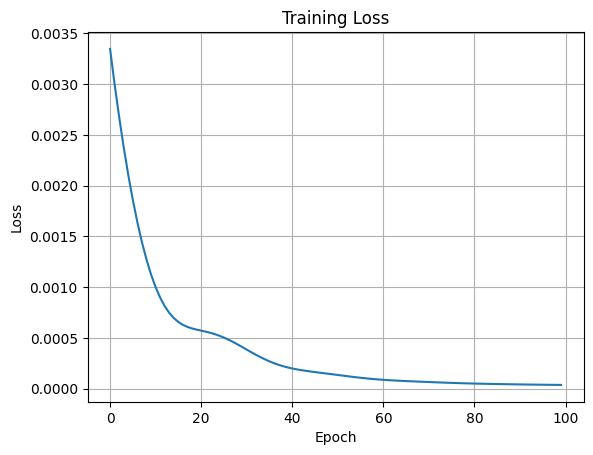

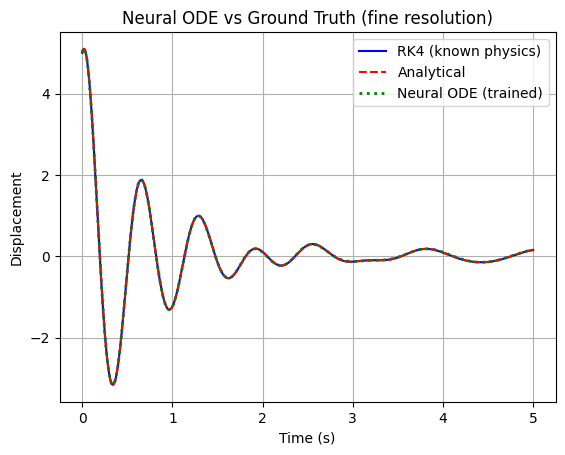

In [5]:

plt.figure()
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

# Validate trained correction_net at fine resolution (dt=0.001)
with torch.no_grad():
    pred_traj_fine = integrate(X0_torch, t_torch, dt)

x_pred_fine = pred_traj_fine[:, 0].numpy()

plt.figure()
plt.plot(t, x_num, 'b-', label='RK4 (known physics)')
plt.plot(t, x_ana, 'r--', label='Analytical')
plt.plot(t, x_pred_fine, 'g:', label='Neural ODE (trained)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Displacement')
plt.legend()
plt.grid(True)
plt.title('Neural ODE vs Ground Truth (fine resolution)')
plt.show()

In [6]:
with torch.no_grad():
    pred_traj_fine = integrate(X0_torch, t_torch, dt)
x_pred_fine = pred_traj_fine[:, 0].numpy()

neural_error = np.abs(x_pred_fine - x_ana)
print(f"Max error (Neural ODE vs analytical): {np.max(neural_error):.6f}")
print(f"Max error (RK4 known physics vs analytical): {np.max(np.abs(x_num - x_ana)):.2e}")

Max error (Neural ODE vs analytical): 0.016903
Max error (RK4 known physics vs analytical): 1.12e-09
